**Overview**  
This notebook describes EACN prediction with [torch-molecule](https://github.com/liugangcode/torch-molecule) models. There are 9 DL models for properties predction (mostly, different types of GNNs). The structure of notebook resembles the one, employing shallow methods. First, we assess model performance with simultaneous optimization of hyperparameters using auto-fit method, embedded in torch-molecule and select the best one. Then we perform final optimization with hyper-opt package and save the best model into *.pt* file

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from torch_molecule import GREAMolecularPredictor
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

In the cell below we import all models from torch_molecule

In [2]:
from torch_molecule import GREAMolecularPredictor, BFGNNMolecularPredictor, SGIRMolecularPredictor, GRINMolecularPredictor, DIRMolecularPredictor, SSRMolecularPredictor, IRMMolecularPredictor, RPGNNMolecularPredictor, GNNMolecularPredictor, LSTMMolecularPredictor


We import dataset, containing EACN values vs SMILES of molecules. SMILES will be the only input for torch_molecule models

In [3]:
dataset = pd.read_csv('targets_with_SMILES_curated.csv', usecols=[1,2,3])

The function calculate_to_score resembles the one, used in notebooks for shallow methods - if finds the best model and save performance metrics into special dictionary. There are three differences: we use *autofit* method of every model to find the optimal hyperparameters, we do not use cross-validation to find metrics and do not draw true values vs predicted values 

In [11]:
def calculate_to_score(estimator, dataset = dataset):
    train, test = train_test_split(dataset, random_state=0, train_size=0.6)
    test, val = train_test_split(test, random_state=0, train_size=0.5)
    
    est = estimator
    best_estimator  = est.autofit(X_train = list(train['SMILES']),
                                        y_train = list(train['EACN']),
                                        X_val = list(val['SMILES']),
                                        y_val = list(val['EACN']), n_trials = 25)
    
    predictions= best_estimator.predict(list(test['SMILES']))['prediction']
    predictions_train = best_estimator.predict(list(train['SMILES']))['prediction']
    scores['Estimator'].append(est.model_name)
    scores['R2_test'].append(r2_score(test['EACN'], predictions))
    scores['R2_train'].append(r2_score(train['EACN'], predictions_train))
        
    scores['RMSE_test'].append(root_mean_squared_error(test['EACN'], predictions))
    scores['RMSE_train'].append(root_mean_squared_error(train['EACN'], predictions_train))

        
    scores['MAE_test'].append(mean_absolute_error(test['EACN'], predictions))
    scores['MAE_train'].append(mean_absolute_error(train['EACN'], predictions_train))

In [115]:
scores = { 'Estimator': [],  'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }
trained_models = {}

Here we make a list of all models instances

In [112]:
models = [GREAMolecularPredictor, BFGNNMolecularPredictor, GRINMolecularPredictor, DIRMolecularPredictor, SSRMolecularPredictor, IRMMolecularPredictor, RPGNNMolecularPredictor,GNNMolecularPredictor]

And make the main calculation

In [116]:
for model in tqdm(models):
    calculate_to_score(model(device = 'cuda:0'))

 38%|███████████████████████████████▏                                                   | 3/8 [13:16<20:40, 248.12s/it][W 2025-07-04 21:47:39,865] Trial 3 failed with parameters: {'gnn_type': 'gcn-virtual', 'norm_layer': 'pair_norm', 'graph_pooling': 'max', 'augmented_feature': None, 'num_layer': 3, 'hidden_size': 464, 'drop_ratio': 0.41575314460635265, 'scheduler_factor': 0.2413131825624616, 'learning_rate': 0.0027737972629664712, 'weight_decay': 6.853143379927221e-07, 'causal_ratio': 0.10817602181159272, 'lw_invariant': 0.00046441704894443434} because of the following error: IndexError('The shape of the mask [110, 1] at index 0 does not match the shape of the indexed tensor [111, 1] at index 0').
Traceback (most recent call last):
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-

Let's see performance metrics for all models

In [5]:
pd.DataFrame(scores)

,Estimator,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,GREAMolecularPredictor,0.528009,4.090079,2.820315,0.793911,3.196848,2.286453
1,BFGNNMolecularPredictor,0.769204,2.860089,1.741172,0.926164,1.913499,1.394539
2,GRINMolecularPredictor,0.418553,4.539627,2.743217,0.917963,2.016974,1.439569
3,DIRMolecularPredictor,0.330648,4.870711,3.598535,0.499446,4.982189,3.882018
4,SSRMolecularPredictor,0.355541,4.779281,3.413294,0.741888,3.577656,2.600044
5,IRMMolecularPredictor,0.751100,2.970145,1.755587,0.975868,1.093941,0.419273
6,RPGNNMolecularPredictor,0.332733,4.863117,2.714975,0.793992,3.196221,1.421267
7,GNNMolecularPredictor,0.783597,2.769472,1.605112,0.979067,1.018847,0.457662


Two models:
1. SGIRMolecular predictor
2. LSTMMolecular predictor

SGIR model requires unlabelled SMILES, LSTM requires the use of NumPy input as target array . First we start with SGIRMolecular predictor, split the dataset into train, test and unlabelled SMILES, get performance metrics and save them into *scores*

In [6]:
sgir = SGIRMolecularPredictor()
train, test = train_test_split(dataset, random_state=0, train_size=0.75)
val, unlb = train_test_split(test, random_state=0, train_size=0.5)

In [10]:
sgir.autofit(X_train = list(train['SMILES']),y_train = list(train['EACN']),
             X_val = list(val['SMILES']),y_val  =list(val['EACN']), X_unlbl = list(unlb['SMILES']))

SGIRMolecularPredictor(device=device(type='cuda', index=0), model_name='SGIRMolecularPredictor', model_class=<class 'torch_molecule.predictor.grea.model.GREA'>, model=GREA(
  (graph_encoder): GNN_node(
    (atom_encoder): AtomEncoder(
      (atom_embedding_list): ModuleList(
        (0): Embedding(120, 395, max_norm=1)
        (1): Embedding(5, 395, max_norm=1)
        (2-3): 2 x Embedding(12, 395, max_norm=1)
        (4): Embedding(10, 395, max_norm=1)
        (5-6): 2 x Embedding(6, 395, max_norm=1)
        (7-8): 2 x Embedding(2, 395, max_norm=1)
      )
    )
    (bond_encoder): BondEncoder(
      (bond_embedding_list): ModuleList(
        (0): Embedding(5, 395, max_norm=1)
        (1): Embedding(6, 395, max_norm=1)
        (2): Embedding(2, 395, max_norm=1)
      )
    )
    (convs): ModuleList(
      (0-2): 3 x GCNConv()
    )
    (batch_norms): ModuleList(
      (0-2): 3 x GraphNorm(395)
    )
  )
  (separator): Separator(
    (rationale_encoder): GNN_node(
      (atom_encoder):

In [12]:
predictions= sgir.predict(list(test['SMILES']))['prediction']
predictions_train = sgir.predict(list(train['SMILES']))['prediction']

scores['Estimator'].append(sgir.model_name)
scores['R2_test'].append(r2_score(test['EACN'], predictions))
scores['R2_train'].append(r2_score(train['EACN'], predictions_train))
        
scores['RMSE_test'].append(root_mean_squared_error(test['EACN'], predictions))
scores['RMSE_train'].append(root_mean_squared_error(train['EACN'], predictions_train))

        
scores['MAE_test'].append(mean_absolute_error(test['EACN'], predictions))
scores['MAE_train'].append(mean_absolute_error(train['EACN'], predictions_train))

Then we perform the same operations with LSTM predictor, which requires the use of target input as Numpy array, not list

In [15]:
train, test = train_test_split(dataset, random_state=0, train_size=0.75)
val, test = train_test_split(test, random_state=0, train_size=0.5)

In [14]:
lstm = LSTMMolecularPredictor()

In [17]:
lstm.autofit(X_train = list(train['SMILES']),
             y_train = np.array(train['EACN']),
             X_val = list(val['SMILES']),
             y_val = np.array(val['EACN']))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([10, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to 

LSTMMolecularPredictor(device=device(type='cuda', index=0), model_name='LSTMMolecularPredictor', model_class=<class 'torch_molecule.predictor.lstm.model.LSTM'>, model=LSTM(
  (embedding): Embedding(54, 32)
  (lstm1): LSTM(32, 85, batch_first=True, bidirectional=True)
  (lstm2): LSTM(170, 85, batch_first=True, bidirectional=True)
  (timedist_dense): Linear(in_features=170, out_features=42, bias=True)
  (relu): ReLU()
  (fc): Linear(in_features=8400, out_features=1, bias=True)
), is_fitted_=True, num_task=1, task_type='regression', input_dim=54, output_dim=32, LSTMunits=85, max_input_len=200, batch_size=128, epochs=500, loss_criterion=MSELoss(), evaluate_criterion=<function mean_absolute_error at 0x00000220D15C3600>, evaluate_higher_better=False, learning_rate=0.00014056858724397628, weight_decay=6.792580563636131e-08, patience=50, use_lr_scheduler=False, scheduler_factor=0.4917045973632216, scheduler_patience=5, verbose=False, fitting_loss=[76.16756057739258, 80.00492095947266, 72.17668

In [18]:
predictions= lstm.predict(list(test['SMILES']))['prediction']
predictions_train = lstm.predict(list(train['SMILES']))['prediction']

scores['Estimator'].append(lstm.model_name)
scores['R2_test'].append(r2_score(test['EACN'], predictions))
scores['R2_train'].append(r2_score(train['EACN'], predictions_train))
        
scores['RMSE_test'].append(root_mean_squared_error(test['EACN'], predictions))
scores['RMSE_train'].append(root_mean_squared_error(train['EACN'], predictions_train))

        
scores['MAE_test'].append(mean_absolute_error(test['EACN'], predictions))
scores['MAE_train'].append(mean_absolute_error(train['EACN'], predictions_train))

Let's get scores for all models in the collection and save them as *.pickle* file

In [64]:
pd.DataFrame(scores)

,Estimator,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,GREAMolecularPredictor,0.528009,4.090079,2.820315,0.793911,3.196848,2.286453
1,BFGNNMolecularPredictor,0.769204,2.860089,1.741172,0.926164,1.913499,1.394539
2,GRINMolecularPredictor,0.418553,4.539627,2.743217,0.917963,2.016974,1.439569
3,DIRMolecularPredictor,0.330648,4.870711,3.598535,0.499446,4.982189,3.882018
4,SSRMolecularPredictor,0.355541,4.779281,3.413294,0.741888,3.577656,2.600044
5,IRMMolecularPredictor,0.751100,2.970145,1.755587,0.975868,1.093941,0.419273
6,RPGNNMolecularPredictor,0.332733,4.863117,2.714975,0.793992,3.196221,1.421267
7,GNNMolecularPredictor,0.783597,2.769472,1.605112,0.979067,1.018847,0.457662
8,SGIRMolecularPredictor,0.797757,2.679540,1.457283,0.977078,1.077708,0.606614
9,LSTMMolecularPredictor,-0.119035,5.836674,4.061872,0.041832,6.967782,5.236877


In [63]:
with open('scores_torch.pickle', 'wb') as output:
    pickle.dump(scores, output)

As we can see, SGIR model have the best generalization performace (highest $R^{2}$, lowest RMSE - about 0.30 lower, than for the best shallow model). We will perform hyperparameter tuning for SGIR using *hyperopt* package and cross-validation as for shallow methods

In [54]:
def objective(params, X):
    SGIR = SGIRMolecularPredictor(num_layer = params['num_layer'], hidden_size = params['hidden_size'], gnn_type = params['gnn_type'], graph_pooling = params['graph_pooling'], weight_decay = params['weight_decay'], use_lr_scheduler = params['use_lr_scheduler'])
    kf = KFold(n_splits = 5)
    cv_rmse_results = []
    cv_mae_results = []
    cv_r2_results = []
    
    for train_unlb_indices, test_indices in kf.split(X):
        
        train_indices, unlbl_indices = train_test_split(train_unlb_indices, random_state = 0, train_size=0.8)
        
        X_train = X.iloc[train_indices, :]['SMILES']
        y_train = X.iloc[train_indices, :]['EACN']
        X_unlbl  = X.iloc[unlbl_indices, :]['SMILES']

        

        X_test = X.iloc[test_indices, :]['SMILES']
        y_test = X.iloc[test_indices, :]['EACN']
        
        sgir.fit(X_train = list(X_train), y_train = list(y_train), X_unlbl = list(X_unlbl))

        predictions = sgir.predict(list(X_test))['prediction']
        
        cv_rmse_results.append(root_mean_squared_error(y_test, predictions))
        cv_mae_results.append(mean_absolute_error(y_test, predictions))
        cv_r2_results.append(r2_score(y_test, predictions))

    return {'loss':np.mean(cv_rmse_results), 'status':STATUS_OK, 'model':sgir, 'r2':-np.mean(cv_r2_results), 'mae':-np.mean(cv_mae_results)}

In [60]:
trials = Trials()

In [58]:
param_grid = {'num_layer': hp.randint('num_layer', 3,7),
              'hidden_size':hp.randint('hidden_size', 200, 400),
              'gnn_type': hp.choice('gnn_type', ["gin-virtual", "gcn-virtual", "gin", "gcn"]),
              'graph_pooling':hp.choice('graph_pooling', ['mean', 'sum', 'max']),
              'weight_decay':hp.loguniform('weight_decay', -13, -4),
              'use_lr_scheduler':hp.choice('use_lr_scheduler', [True, False])}
                                    

In [61]:
best = fmin(partial(objective, X = dataset), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  25)

  0%|                                                                           | 0/25 [00:00<?, ?trial/s, best loss=?]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

  4%|█▉                                               | 1/25 [01:16<30:24, 76.02s/trial, best loss: 3.2210374437034113]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

  8%|███▉                                             | 2/25 [02:20<26:36, 69.41s/trial, best loss: 3.0785211986538448]

...

 92%|████████████████████████████████████████████▏   | 23/25 [29:29<02:33, 76.92s/trial, best loss: 2.6453768048881083]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

 96%|██████████████████████████████████████████████  | 24/25 [31:13<01:25, 85.06s/trial, best loss: 2.6453768048881083]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided

100%|████████████████████████████████████████████████| 25/25 [32:30<00:00, 78.04s/trial, best loss: 2.6453768048881083]


In [62]:
print(best)

{'gnn_type': 2, 'graph_pooling': 1, 'hidden_size': 386, 'num_layer': 6, 'use_lr_scheduler': 0, 'weight_decay': 0.00034557692070604184}


Let's finally fit the best estimator with optimal hyperparameters and plot predicted values vs true ones for test dataset

In [24]:
train, test = train_test_split(dataset, random_state=0, train_size=0.8)
train, unlbl = train_test_split(train, random_state=0, train_size=0.9)

In [25]:
sgir = SGIRMolecularPredictor(gnn_type='gin', graph_pooling='sum', hidden_size=386, num_layer=6, use_lr_scheduler=True, weight_decay=0.00034557692070604184)
sgir.fit(X_train = list(train['SMILES']),
               y_train=list(train['EACN']),
               X_unlbl = list(unlbl['SMILES']))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(


SGIRMolecularPredictor(device=device(type='cuda', index=0), model_name='SGIRMolecularPredictor', model_class=<class 'torch_molecule.predictor.grea.model.GREA'>, model=GREA(
  (graph_encoder): GNN_node(
    (atom_encoder): AtomEncoder(
      (atom_embedding_list): ModuleList(
        (0): Embedding(120, 386, max_norm=1)
        (1): Embedding(5, 386, max_norm=1)
        (2-3): 2 x Embedding(12, 386, max_norm=1)
        (4): Embedding(10, 386, max_norm=1)
        (5-6): 2 x Embedding(6, 386, max_norm=1)
        (7-8): 2 x Embedding(2, 386, max_norm=1)
      )
    )
    (bond_encoder): BondEncoder(
      (bond_embedding_list): ModuleList(
        (0): Embedding(5, 386, max_norm=1)
        (1): Embedding(6, 386, max_norm=1)
        (2): Embedding(2, 386, max_norm=1)
      )
    )
    (convs): ModuleList(
      (0-5): 6 x GINConv()
    )
    (batch_norms): ModuleList(
      (0-5): 6 x BatchNorm1d(386, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (separator): S

RMSE of predictor for test set is 2.729112882172045
R2 value of predictor for test set is 0.7934403346054232
MAE value for test set is 1.7478657837693907


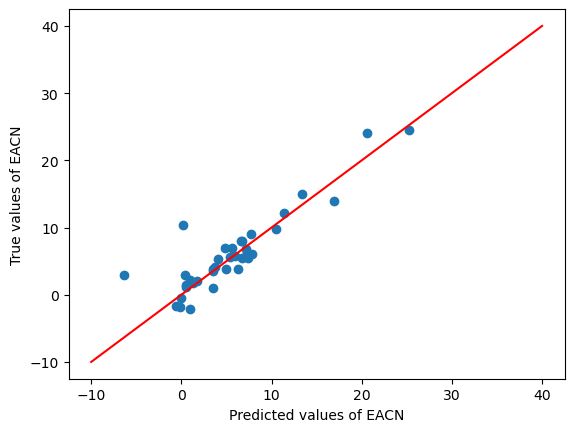

In [26]:
predictions = sgir.predict(list(test['SMILES']))

plt.plot(predictions['prediction'], test['EACN'], 'o')
plt.plot([-10, 40], [-10,40], 'r')
plt.xlabel('Predicted values of EACN')
plt.ylabel('True values of EACN')

print('RMSE of predictor for test set is {}'.format(root_mean_squared_error(predictions['prediction'], test['EACN'])))
print('R2 value of predictor for test set is {}'.format(r2_score(predictions['prediction'], test['EACN'])))
print('MAE value for test set is {}'.format(mean_absolute_error(predictions['prediction'], test['EACN'])))

Then we finally fit the whole model for use in predictions calculator

In [33]:
train, unlbl = train_test_split(dataset, random_state=0, train_size=0.90)
sgir_final = SGIRMolecularPredictor(gnn_type='gin', graph_pooling='sum', hidden_size=386, num_layer=6, use_lr_scheduler=True, weight_decay=0.00034557692070604184)
sgir_final.fit(X_train = list(train['SMILES']), y_train = list(train['EACN']), X_unlbl = list(unlbl['SMILES']))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\sgir\modeling_sgir.py:121: UserWarning: No validation set provided. Using training set for validation.
  warnings.warn(


SGIRMolecularPredictor(device=device(type='cuda', index=0), model_name='SGIRMolecularPredictor', model_class=<class 'torch_molecule.predictor.grea.model.GREA'>, model=GREA(
  (graph_encoder): GNN_node(
    (atom_encoder): AtomEncoder(
      (atom_embedding_list): ModuleList(
        (0): Embedding(120, 386, max_norm=1)
        (1): Embedding(5, 386, max_norm=1)
        (2-3): 2 x Embedding(12, 386, max_norm=1)
        (4): Embedding(10, 386, max_norm=1)
        (5-6): 2 x Embedding(6, 386, max_norm=1)
        (7-8): 2 x Embedding(2, 386, max_norm=1)
      )
    )
    (bond_encoder): BondEncoder(
      (bond_embedding_list): ModuleList(
        (0): Embedding(5, 386, max_norm=1)
        (1): Embedding(6, 386, max_norm=1)
        (2): Embedding(2, 386, max_norm=1)
      )
    )
    (convs): ModuleList(
      (0-5): 6 x GINConv()
    )
    (batch_norms): ModuleList(
      (0-5): 6 x BatchNorm1d(386, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (separator): S

In [34]:
sgir_final.save_to_local('sgir_final.pt')